# ECE313: Probability with Engineering Applications

## Project I: Failure Data Analysis

Project setup / given data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
# Raw data - Failures times for Air conditioners in 11 Airplanes
# setup as dictionary with a list value order by T1 to T16

data = {
    7907: [194, 209, 250, 279, 312, 493],
    7908: [413, 427, 485, 522, 622, 687, 696, 865],
    7909: [90, 100, 160, 346, 407, 456, 470, 494, 550, 570, 649, 733, 777, 836, 865, 983],
    7910: [74, 131, 179, 208, 710, 722, 792, 813, 842],
    7911: [55, 375, 431, 535, 755, 994],
    7912: [23, 284, 371, 378, 498, 512, 574, 621, 846, 917],
    7913: [97, 148, 159, 163, 304, 322, 464, 532, 609, 689, 690, 706, 812],
    7914: [50, 94, 196, 268, 290, 329, 332, 347, 544, 732, 811, 899, 945, 950, 955, 991],
    7915: [359, 368, 380, 650],
    7916: [50, 304, 309, 592, 627, 639],
    7917: [130, 623],
}

### Task 1: Calculate the inter-failure times for each airplane’s air conditioning unit and conduct corresponding descriptive statistical analysis. Can differences in repair patterns between individuals be observed from the visualization results? 


In [4]:
# calculation - failure times are cumulative; inter-failure times are the differences between consecutive times
inter_failure = {}
for plane, times in data.items():
    diff = np.diff([0] + times)
    inter_failure[plane] = diff

C:\Users\User\AppData\Local\Temp\ipykernel_55096\1473478625.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(inter_failure.values(), labels=inter_failure.keys())


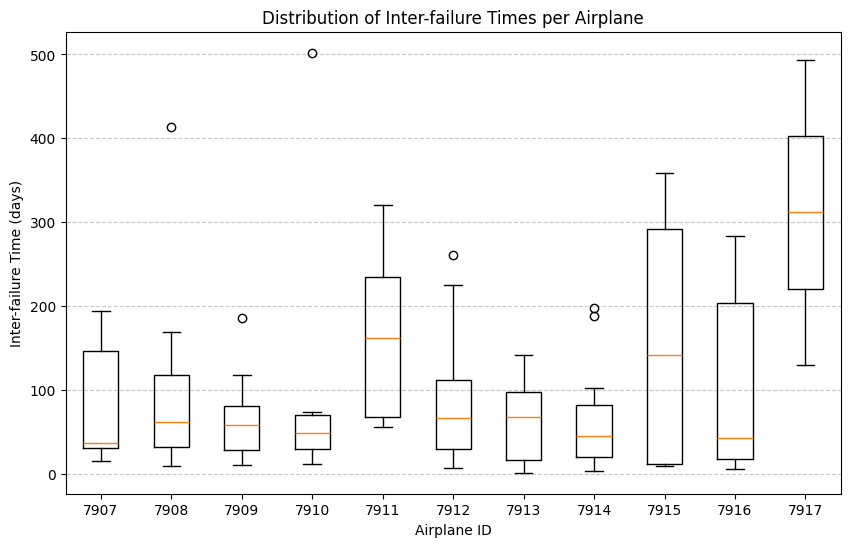

In [5]:
# boxplot per airplane
fig1 = plt.figure(figsize= (10, 6))
plt.boxplot(inter_failure.values(), labels=inter_failure.keys())
plt.xlabel("Airplane ID")
plt.ylabel("Inter-failure Time (days)")
plt.title("Distribution of Inter-failure Times per Airplane")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

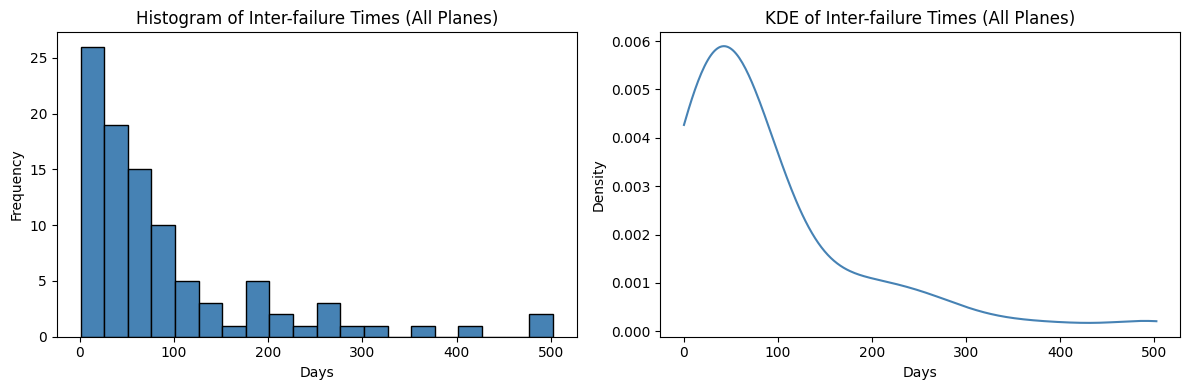

In [6]:
# histograms/KDE of pooled inter-failure times (ift)

all_ift = np.concatenate(list(inter_failure.values()))

fig2, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(all_ift, bins=20, edgecolor='black', color='steelblue')
axes[0].set_title("Histogram of Inter-failure Times (All Planes)")
axes[0].set_xlabel("Days")
axes[0].set_ylabel("Frequency")

axes[1].set_title("KDE of Inter-failure Times (All Planes)")
from scipy.stats import gaussian_kde
kde = gaussian_kde(all_ift)
x = np.linspace(0, max(all_ift), 300)
axes[1].plot(x, kde(x), color='steelblue')
axes[1].set_xlabel("Days")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

In [7]:
#summary findings

summary = pd.DataFrame({
    plane: pd.Series(ift).describe()
    for plane, ift in inter_failure.items()
}).T.round(2)

print(summary)

      count    mean     std    min     25%    50%     75%    max
7907    6.0   82.17   82.13   15.0   30.00   37.0  146.00  194.0
7908    8.0  108.12  133.54    9.0   31.25   61.5  117.25  413.0
7909   16.0   61.44   44.66   10.0   27.75   57.5   80.25  186.0
7910    9.0   93.56  154.69   12.0   29.00   48.0   70.00  502.0
7911    6.0  165.67  109.75   55.0   68.00  162.0  234.25  320.0
7912   10.0   91.70   87.24    7.0   29.00   66.5  111.75  261.0
7913   13.0   62.46   50.20    1.0   16.00   68.0   97.00  142.0
7914   16.0   61.94   59.15    3.0   20.25   45.0   81.25  197.0
7915    4.0  162.50  179.24    9.0   11.25  141.0  292.25  359.0
7916    6.0  106.50  126.84    5.0   17.75   42.5  203.00  283.0
7917    2.0  311.50  256.68  130.0  220.75  311.5  402.25  493.0


findings:

The boxplot reveals notable heterogeneity across the 11 airplanes. Aircraft such as 7909 and 7914 exhibit shorter median inter-failure times and higher failure counts, suggesting a higher underlying failure rate. In contrast, aircraft 7915 and 7917 show fewer failures with longer inter-failure intervals. The variability (IQR and range) also differs substantially between units — some aircraft show consistent failure spacing while others display high variance, indicating that repair patterns are not uniform across individuals. This heterogeneity motivates caution when pooling data under a single homogeneous model.

### Task 2: Order the unique failure times for all air conditioners and compute the mean cumulative repair function (MCRF). Plot the cumulative plot of MCRF. Are the systems experiencing more failures as time goes by?

formula:
$$
\hat{M}(t_j​)=\hat{M}(t_{j-1}​)+ \frac{1}{n_j​}​
$$

where $n_j​$ is the number of units still under observation at time $t_j$.

In [8]:
# Collect all (time, plane) failure events
all_events = []
for plane, times in data.items():
    for t in times:
        all_events.append((t, plane))

all_events.sort()  # sort by time

# For MCRF: at each unique failure time, increment by 1/n_at_risk
# All 11 planes are observed from 0 to their last recorded time
end_times = {plane: max(times) for plane, times in data.items()}
n_planes = len(data)

unique_times = sorted(set(t for t, _ in all_events))
mcrf = []
cumulative = 0

# formula
for t in unique_times:
    # Count planes still at risk (last failure >= t)
    n_at_risk = sum(1 for plane, end in end_times.items() if end >= t)
    # Count failures at this time
    failures_at_t = sum(1 for time, _ in all_events if time == t)
    cumulative += failures_at_t / n_at_risk
    mcrf.append((t, cumulative))

mcrf_df = pd.DataFrame(mcrf, columns=['time', 'MCRF'])

mcrf_df

,time,MCRF
0,23,0.090909
1,50,0.272727
2,55,0.363636
3,74,0.454545
4,90,0.545455
...,...,...
88,950,10.693434
89,955,11.026768
90,983,11.360101
91,991,11.860101


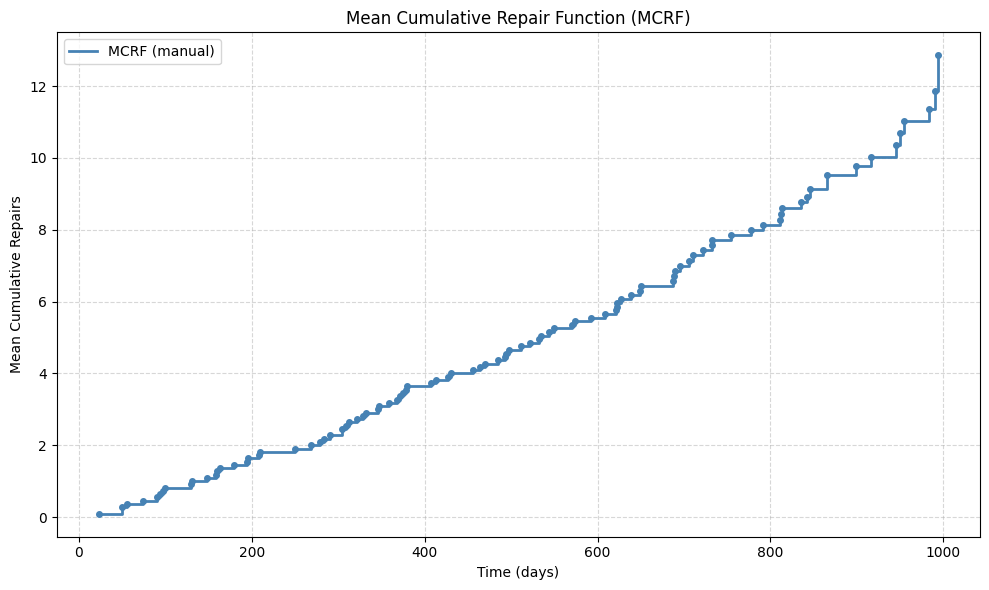

In [9]:
# plot - step function

# After computing your mcrf list of (time, cumulative) tuples
times_mcrf = [t for t, _ in mcrf]
values_mcrf = [v for _, v in mcrf]

fig, ax = plt.subplots(figsize=(10, 6))

# Step function — drawstyle='steps-post' is key
ax.step(times_mcrf, values_mcrf, where='post', color='steelblue', linewidth=2, label='MCRF (manual)')

# Add dots at each failure event
ax.plot(times_mcrf, values_mcrf, 'o', color='steelblue', markersize=4)

ax.set_xlabel("Time (days)")
ax.set_ylabel("Mean Cumulative Repairs")
ax.set_title("Mean Cumulative Repair Function (MCRF)")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


verify result by using RELIABILITY python lib

Mean Cumulative Function results (95% CI):
state  time MCF_lower       MCF MCF_upper   variance
    F    23 0.0189453 0.0909091  0.436229 0.00751315
    F    50 0.0599822  0.181818  0.551128  0.0150263
    F    50  0.110279  0.272727  0.674475  0.0225394
    F    55  0.166002  0.363636  0.796564  0.0300526
    F    74  0.225412  0.454545  0.916595  0.0375657
    F    90   0.28754  0.545455   1.03471  0.0450789
    F    94   0.35178  0.636364   1.15117   0.052592
    F    97  0.417724  0.727273   1.26621  0.0601052
    F   100  0.485081  0.818182   1.38002  0.0676183
    F   130  0.553634  0.909091   1.49277  0.0751315
    F   131  0.623216         1   1.60458  0.0826446
    F   148  0.693697   1.09091   1.71556  0.0901578
    F   159  0.764972   1.18182   1.82581  0.0976709
    F   160  0.836955   1.27273   1.93539   0.105184
    F   163  0.909573   1.36364   2.04437   0.112697
    F   179  0.982767   1.45455    2.1528    0.12021
    F   194   1.05649   1.54545   2.26073   0.127724
   

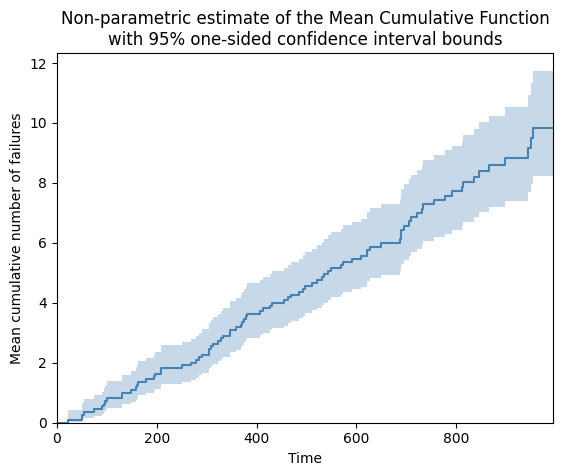

In [12]:
from reliability.Repairable_systems import MCF_nonparametric

times = list(data.values()) 

MCF_nonparametric(data=times)
plt.show()

Mean Cumulative Function Parametric Model (95% CI):
MCF = (t/α)^β
Parameter  Point Estimate  Standard Error  Lower CI  Upper CI
    Alpha         133.084         1.61163   129.963   136.281
     Beta         1.14475      0.00846215   1.12828   1.16146 

Since Beta is greater than 1, the system repair rate is WORSENING over time.


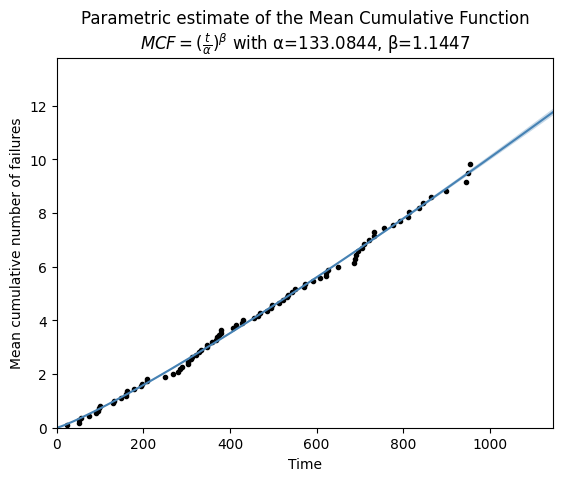

In [13]:
from reliability.Repairable_systems import MCF_parametric

MCF_parametric(data=times)
plt.show()

Findings: Yes - systems experiencing more failures as time increases based on the exponential characteristic of the MCRF graph

### Task 3: Disregarding the heterogeneity among units, calculate the number of failures occurring within each time interval. Choose either a homogeneous or non-homogeneous Poisson Process to model the failure count data, and provide a reasonable explanation

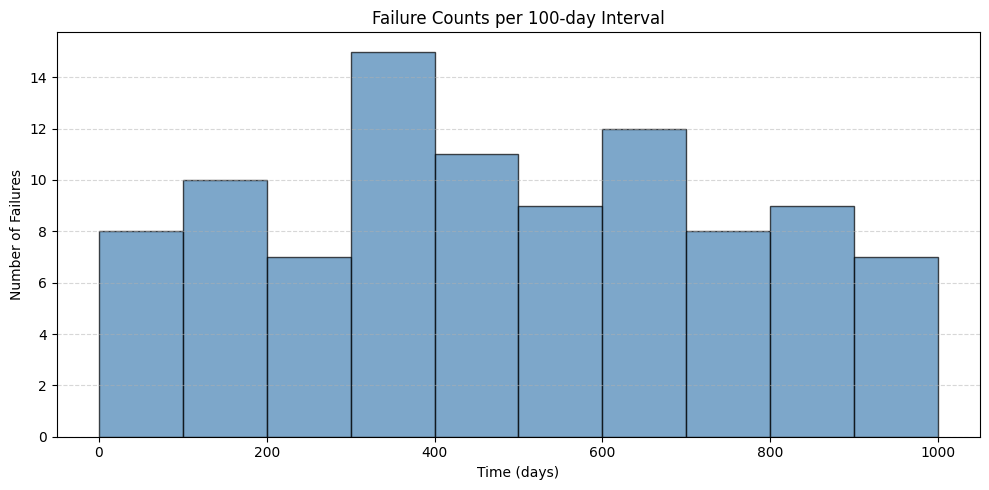

Interval counts: [ 8 10  7 15 11  9 12  8  9  7]


In [20]:
# step1 Count failures in time intervals

# Pool all failure times
all_times_flat = sorted([t for times in data.values() for t in times])

# Define intervals (e.g. every 100 days)
bins = np.arange(0, 1100, 100)
counts, edges = np.histogram(all_times_flat, bins=bins)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(edges[:-1], counts, width=100, edgecolor='black', 
       color='steelblue', alpha=0.7, align='edge')
ax.set_xlabel("Time (days)")
ax.set_ylabel("Number of Failures")
ax.set_title("Failure Counts per 100-day Interval")
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("Interval counts:", counts)

In [22]:
# step2 Run a formal trend test (using Laplace Trend Test)
n = len(all_times_flat)
T = max(all_times_flat)

# Laplace statistic
L = (np.mean(all_times_flat) - T/2) / (T * np.sqrt(1/(12*n)))
print(f"Laplace statistic L = {L:.4f}")
print(f"Critical value at 5% significance = ±1.96")

if abs(L) > 1.96:
    print("Reject HPP: trend exists, use NHPP")
    if L > 0:
        print("L > 0: failure rate is INCREASING over time")
    else:
        print("L < 0: failure rate is DECREASING over time")
else:
    print("Fail to reject HPP: no significant trend, HPP is appropriate")

Laplace statistic L = -0.2394
Critical value at 5% significance = ±1.96
Fail to reject HPP: no significant trend, HPP is appropriate


Mean Cumulative Function Parametric Model (95% CI):
MCF = (t/α)^β
Parameter  Point Estimate  Standard Error  Lower CI  Upper CI
    Alpha         133.084         1.61163   129.963   136.281
     Beta         1.14475      0.00846215   1.12828   1.16146 

Since Beta is greater than 1, the system repair rate is WORSENING over time.


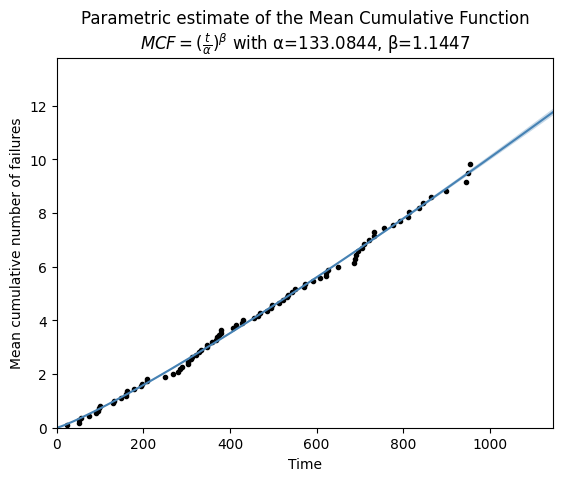

In [23]:
from reliability.Repairable_systems import MCF_parametric

# Get beta from parametric MCF fit
MCF_parametric(data=list(data.values()))
plt.show()

Findings:

The Laplace trend test fails to reject HPP (L = -0.2394), however this test has limited power with only 11 systems. The parametric MCRF fit yields β = 1.1447 with a 95% CI of [1.128, 1.161], which entirely excludes β = 1. This provides stronger evidence of a mild but statistically significant increasing failure rate. Therefore, an NHPP with Power Law intensity is selected as the more appropriate model.

### Task 4: Estimate the parameters of your model and apply the fitted model to the data. Evaluate whether the model provides a good fit. How can you assess the goodness-of-fit for your model?

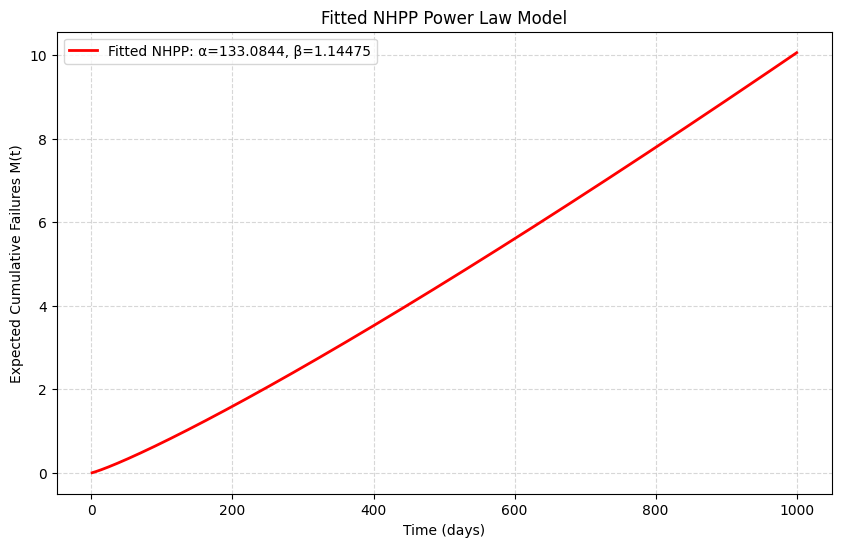

In [38]:
# Formally state the model

alpha_hat = 133.0844
beta_hat = 1.14475

# NHPP Power Law intensity function
# lambda(t) = (beta/alpha) * (t/alpha)^(beta-1)
# Expected cumulative failures: M(t) = (t/alpha)^beta

t_range = np.linspace(1, 1000, 1000)
M_fitted = (t_range / alpha_hat) ** beta_hat

plt.figure(figsize=(10, 6))
plt.plot(t_range, M_fitted, color='red', linewidth=2, label=f'Fitted NHPP: α={alpha_hat}, β={beta_hat}')
plt.xlabel("Time (days)")
plt.ylabel("Expected Cumulative Failures M(t)")
plt.title("Fitted NHPP Power Law Model")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

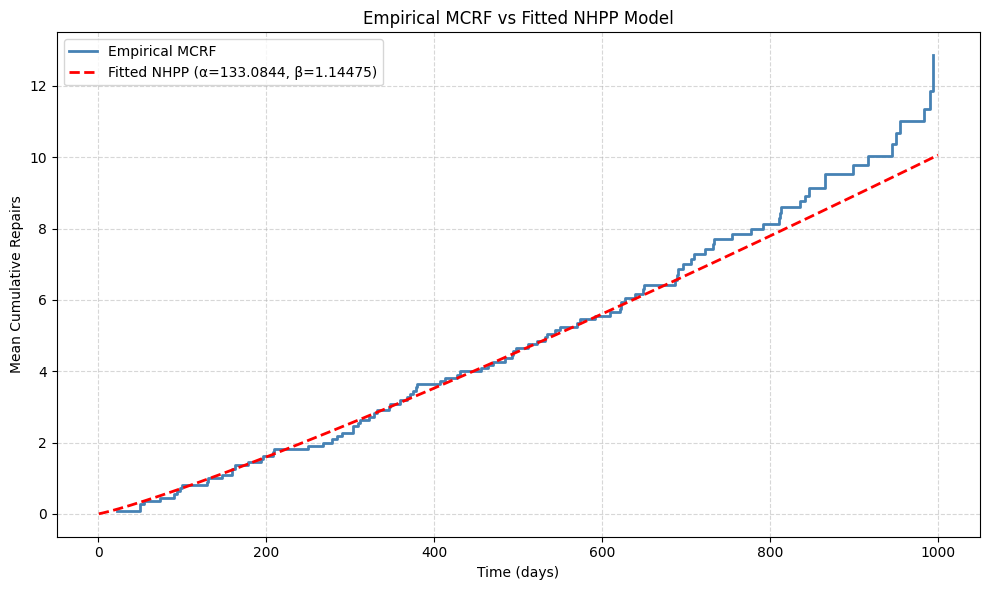

In [39]:
#  Overlay fitted model on manual MCRF

fig, ax = plt.subplots(figsize=(10, 6))

# Manual MCRF step function
ax.step(times_mcrf, values_mcrf, where='post', 
        color='steelblue', linewidth=2, label='Empirical MCRF')

# Fitted NHPP curve
ax.plot(t_range, M_fitted, color='red', linewidth=2, 
        linestyle='--', label=f'Fitted NHPP (α={alpha_hat}, β={beta_hat})')

ax.set_xlabel("Time (days)")
ax.set_ylabel("Mean Cumulative Repairs")
ax.set_title("Empirical MCRF vs Fitted NHPP Model")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

The fitted NHPP model closely follows the empirical MCRF up to approximately day 700. The divergence at later times is attributed to the reduced number of systems under observation, which inflates the manual MCRF estimate due to the $ \frac{1}{n_j} $ increments becoming larger as $ n_j $ decreases.

maybe better to use the library's non-parametric MCRF instead of the manual one

In [42]:
# Goodness-of-Fit: Chi-squared test

from scipy.stats import chi2

# Use same bins as Task 3
bins = np.arange(0, 1100, 100)
observed, edges = np.histogram(all_times_flat, bins=bins)

# Expected counts from fitted NHPP model
# E(failures in [a,b]) = M(b) - M(a) = (b/alpha)^beta - (a/alpha)^beta
expected = []
for i in range(len(edges)-1):
    a, b = edges[i], edges[i+1]
    interval_expected = 0
    for plane_times in data.values():
        T_end = max(plane_times)
        # Only include plane if it's observed during this interval
        if T_end > a:
            b_eff = min(b, T_end)  # clip to plane's observation end
            Ma = (a/alpha_hat)**beta_hat if a > 0 else 0
            Mb = (b_eff/alpha_hat)**beta_hat
            interval_expected += (Mb - Ma)
    expected.append(interval_expected)

expected = np.array(expected)
print(f"Observed counts:  {observed}")
print(f"Expected counts:  {np.round(expected, 2)}")

# Chi-squared statistic
chi2_stat = np.sum((observed - expected)**2 / expected)
dof = len(observed) - 2 - 1  # bins - parameters estimated - 1
p_value = 1 - chi2.cdf(chi2_stat, dof)

print(f"Observed counts:  {observed}")
print(f"Expected counts:  {np.round(expected, 2)}")
print(f"Chi-squared stat: {chi2_stat:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_value:.4f}")

if p_value > 0.05:
    print("Fail to reject: NHPP model fits the data well")
else:
    print("Reject: model does not fit well")

Observed counts:  [ 8 10  7 15 11  9 12  8  9  7]
Expected counts:  [ 7.93  9.6  10.36 10.88 11.21 10.56  8.78  7.73  5.83  3.25]
Observed counts:  [ 8 10  7 15 11  9 12  8  9  7]
Expected counts:  [ 7.93  9.6  10.36 10.88 11.21 10.56  8.78  7.73  5.83  3.25]
Chi-squared stat: 10.1238
Degrees of freedom: 7
p-value: 0.1817
Fail to reject: NHPP model fits the data well


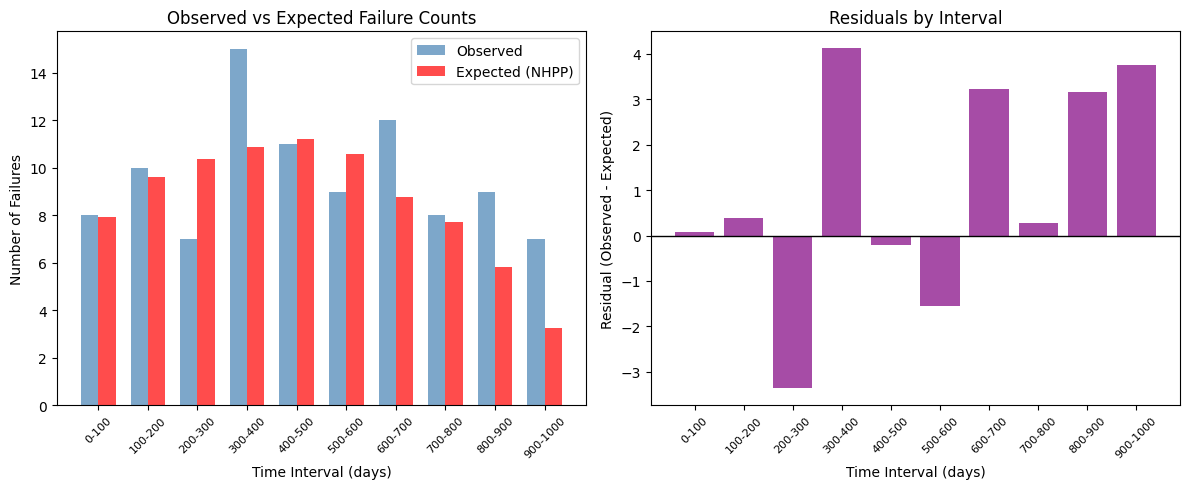

In [43]:
# Goodness-of-Fit: Visual residual check

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Observed vs Expected bar chart
x = np.arange(len(observed))
width = 0.35
axes[0].bar(x - width/2, observed, width, label='Observed', color='steelblue', alpha=0.7)
axes[0].bar(x + width/2, expected, width, label='Expected (NHPP)', color='red', alpha=0.7)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'{int(edges[i])}-{int(edges[i+1])}' for i in range(len(observed))], 
                         rotation=45, fontsize=8)
axes[0].set_xlabel("Time Interval (days)")
axes[0].set_ylabel("Number of Failures")
axes[0].set_title("Observed vs Expected Failure Counts")
axes[0].legend()

# Plot 2: Residuals
residuals = observed - expected
axes[1].bar(x, residuals, color='purple', alpha=0.7)
axes[1].axhline(y=0, color='black', linewidth=1)
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'{int(edges[i])}-{int(edges[i+1])}' for i in range(len(observed))], 
                         rotation=45, fontsize=8)
axes[1].set_xlabel("Time Interval (days)")
axes[1].set_ylabel("Residual (Observed - Expected)")
axes[1].set_title("Residuals by Interval")

plt.tight_layout()
plt.show()

Findings:

Parameter Estimation: The NHPP Power Law model was fitted using the reliability library, yielding α = 133.08 and β = 1.1447 with 95% CI [1.128, 1.161].


Goodness-of-Fit: The chi-squared test yields χ² = 10.12 (df = 7, p = 0.1817). Since p > 0.05 we fail to reject the null hypothesis, indicating the model provides an adequate fit. Visual inspection of the observed vs expected counts and residual plot confirms the model captures the overall failure trend well, though some local deviations exist — particularly in the 300-400 day interval — which may reflect individual heterogeneity among aircraft units.